<a href="https://colab.research.google.com/github/Rojoniaina-Rasoafarihy/Evo2_project/blob/main/RF_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, confusion_matrix, f1_score)
from collections import Counter
from pathlib import Path
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load embeddings and labels
LABEL_FILE = "gs://rojo_project/isolation_source_labels.csv"

In [ ]:
!mkdir -p /home/jupyter/data

In [ ]:
!gsutil -m cp -r gs://rojo_project/evo2_embeddings_npz /home/jupyter/data/

In [ ]:
!ls /home/jupyter/data

evo2_embeddings_npz


In [ ]:
import os
EMB_DIR = "/home/jupyter/data/evo2_embeddings_npz"

all_embeddings = []
all_labels = []

files = [f for f in os.listdir(EMB_DIR) if f.endswith(".npz")]

print("Embedding files:", len(files))

Embedding files: 29920


In [ ]:
# Load labels

label_df = pd.read_csv(LABEL_FILE)
label_dict = dict(zip(label_df["Assembly"], label_df["isolation source"]))

X_list = []
y_list = []
stems = []
# load embedding
EMB_DIR = Path("/home/jupyter/data/evo2_embeddings_npz")

for npz_path in EMB_DIR.glob("*.npz"):
    stem = npz_path.stem
    if stem not in label_dict:
        continue
    data = np.load(npz_path)
    X_list.append(data["embedding"])
    y_list.append(label_dict[stem])
    stems.append(stem)

X = np.array(X_list)          # (n_samples, 8192)
y = np.array(y_list)

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"Classes: {le.classes_}")
print(f"Loaded {len(X)} genomes")
print(f"Embedding shape: {X.shape}")
print(f"Unique isolation sources: {np.unique(y)}")

Classes: ['Air' 'Bird' 'Bloodstream' 'Bone_Joint' 'CF_Respiratory' 'Crop'
 'Domestic' 'Ear_Nose_Throat' 'Experimental' 'Gastrointestinal' 'Hospital'
 'Industrial' 'Lab_Strain' 'Marine' 'Medical_Device' 'Ocular'
 'Reproductive' 'Respiratory' 'Skin_Soft_Tissue' 'Soil' 'Urinary' 'Water']


In [ ]:
clinical_mapping = {
    # High urgency - direct clinical action
    'Bloodstream': 'Bloodstream',
    'Respiratory': 'Respiratory',
    'CF_Respiratory': 'Respiratory',

    # Moderate urgency
    'Urinary': 'Urinary',
    'Gastrointestinal': 'Gastrointestinal',
    'Wound': 'Wound_Skin',
    'Skin_Soft_Tissue': 'Wound_Skin',
    'Medical_Device': 'Medical_Device',
    'Hospital': 'Medical_Device',

    # Low urgency / environmental
    'Air': 'Environmental',
    'Water': 'Environmental',
    'Soil': 'Environmental',
    'Crop': 'Environmental',
    'Domestic': 'Environmental',
    'Industrial': 'Environmental',
    'Marine': 'Environmental',
    'Lab_Strain': 'Environmental',

    # Other clinical (rare, monitor but low priority)
    'Ocular': 'Other_Clinical',
    'Reproductive': 'Other_Clinical',
    'Bone_Joint': 'Other_Clinical',
    'Ear_Nose_Throat': 'Other_Clinical',
    'Bird': 'Other_Clinical',
    'Experimental': 'Other_Clinical',
}



In [ ]:
# Apply mapping
y_mapped = [clinical_mapping.get(label, 'Environmental') for label in y]

# Count distribution
class_counts = Counter(y_mapped)
print("Classes after clinical mapping:")
for cls, cnt in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {cls}: {cnt}")

# Filter classes with at least min_samples
min_samples = 5
keep_classes = [cls for cls, cnt in class_counts.items() if cnt >= min_samples]
print(f"\nKeeping classes with ≥{min_samples} samples: {keep_classes}")

mask = [label in keep_classes for label in y_mapped]
X_filtered = X[mask]
y_filtered = [y_mapped[i] for i in range(len(mask)) if mask[i]]
genome_names_filtered = [stems[i] for i in range(len(mask)) if mask[i]]

# Encode labels to integers
le = LabelEncoder()
y_enc = le.fit_transform(y_filtered)
class_names = le.classes_
print(f"\nFinal classes: {class_names}")
print(f"Class counts: {dict(zip(class_names, Counter(y_enc).values()))}")

Classes after clinical mapping:
  Respiratory: 15558
  Urinary: 3383
  Wound_Skin: 2589
  Bloodstream: 2430
  Environmental: 1767
  Medical_Device: 1741
  Gastrointestinal: 1315
  Other_Clinical: 1137

Keeping classes with ≥5 samples: ['Respiratory', 'Bloodstream', 'Medical_Device', 'Urinary', 'Environmental', 'Other_Clinical', 'Wound_Skin', 'Gastrointestinal']

Final classes: ['Bloodstream' 'Environmental' 'Gastrointestinal' 'Medical_Device'
 'Other_Clinical' 'Respiratory' 'Urinary' 'Wound_Skin']
Class counts: {np.str_('Bloodstream'): 15558, np.str_('Environmental'): 2430, np.str_('Gastrointestinal'): 1741, np.str_('Medical_Device'): 3383, np.str_('Other_Clinical'): 1767, np.str_('Respiratory'): 1137, np.str_('Urinary'): 2589, np.str_('Wound_Skin'): 1315}


In [ ]:
#cross validation : randomforest
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Storage for all folds
all_y_true = []
all_y_pred = []
all_y_proba = []
fold_accuracies = []
fold_f1_macro = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_filtered, y_enc)):
    X_train, X_test = X_filtered[train_idx], X_filtered[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # RandomForest with class balancing
    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=30,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = clf.predict(X_test_scaled)
    y_proba = clf.predict_proba(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    fold_accuracies.append(acc)
    fold_f1_macro.append(f1_macro)

    print(f"Fold {fold+1}: Accuracy={acc:.4f}, F1-macro={f1_macro:.4f}")

    # Store for overall evaluation
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_proba.append(y_proba)

# Combine probabilities
all_y_proba = np.vstack(all_y_proba)

Fold 1: Accuracy=0.5558, F1-macro=0.3017
Fold 2: Accuracy=0.5561, F1-macro=0.3045
Fold 3: Accuracy=0.5655, F1-macro=0.3182
Fold 4: Accuracy=0.5600, F1-macro=0.3127
Fold 5: Accuracy=0.5587, F1-macro=0.3136


In [ ]:
print(f"Mean CV Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"Mean CV F1-macro: {np.mean(fold_f1_macro):.4f} (+/- {np.std(fold_f1_macro):.4f})")

print("\nClassification Report (all folds combined):")
print(classification_report(all_y_true, all_y_pred, target_names=class_names))

if len(class_names) >= 2:
    auc_macro = roc_auc_score(all_y_true, all_y_proba, multi_class='ovr', average='macro')
    print(f"\nMacro ROC-AUC: {auc_macro:.4f}")

Mean CV Accuracy: 0.5592 (+/- 0.0035)
Mean CV F1-macro: 0.3102 (+/- 0.0061)

Classification Report (all folds combined):
                  precision    recall  f1-score   support

     Bloodstream       0.43      0.08      0.13      2430
   Environmental       0.59      0.27      0.37      1767
Gastrointestinal       0.40      0.20      0.27      1315
  Medical_Device       0.46      0.29      0.35      1741
  Other_Clinical       0.52      0.21      0.30      1137
     Respiratory       0.59      0.92      0.72     15558
         Urinary       0.37      0.15      0.21      3383
      Wound_Skin       0.32      0.08      0.13      2589

        accuracy                           0.56     29920
       macro avg       0.46      0.27      0.31     29920
    weighted avg       0.51      0.56      0.48     29920


Macro ROC-AUC: 0.7745


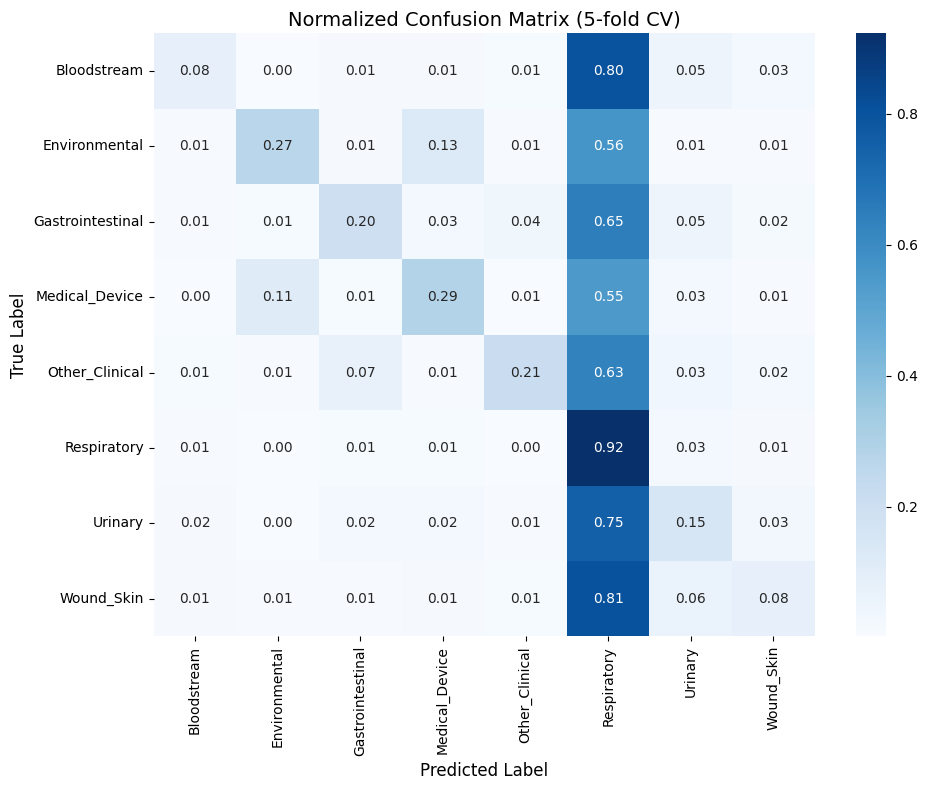

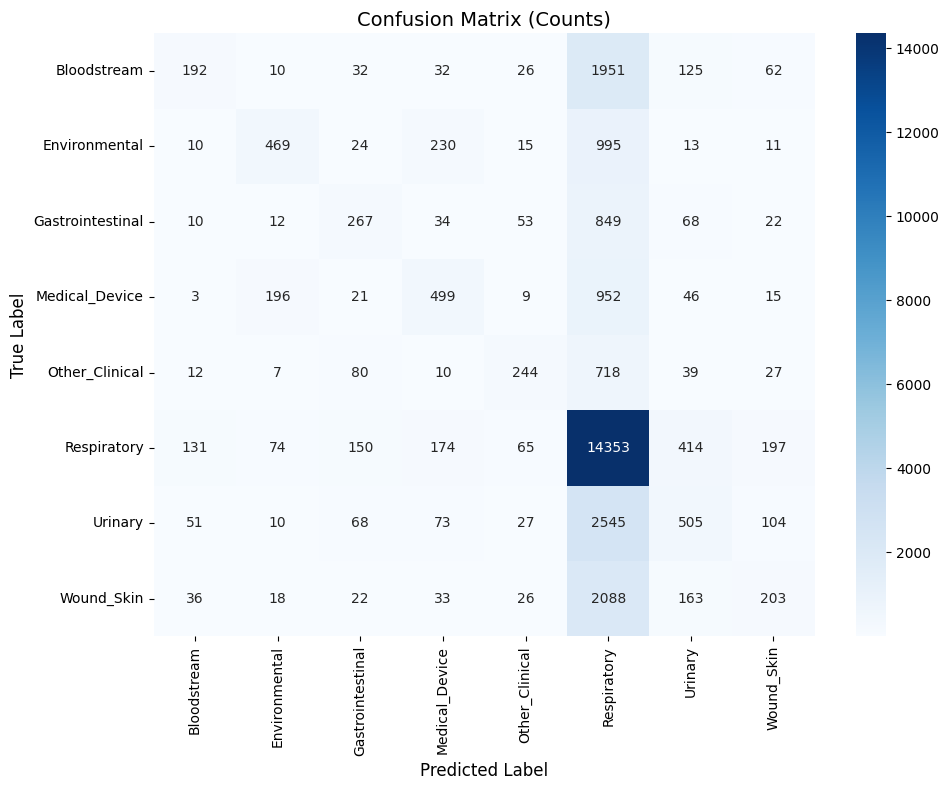

In [ ]:
cm = confusion_matrix(all_y_true, all_y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix (5-fold CV)', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_normalized.png', dpi=150)
plt.show()

# Plot raw counts
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Counts)', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_counts.png', dpi=150)
plt.show()